# Agglomerative Clustering (Complete Linkage) with PCA, 2D/3D Visualization, MAACLI, and Optuna
This notebook focuses solely on Agglomerative Clustering using complete linkage, includes PCA-based 2D and 3D plots, integrates MAACLI insights, and optionally uses Optuna to optimize the number of clusters.

In [5]:
# Core data manipulation and numerical libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn components
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import AgglomerativeClustering

# Hyperparameter optimization
import optuna

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [6]:
df = pd.read_csv('data/typhoon_impact_with_extreme_weather.csv')
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1776 entries, 0 to 1775
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Typhoon Name             1776 non-null   object 
 1   Year                     1776 non-null   int64  
 2   Region                   1776 non-null   int64  
 3   Province                 1776 non-null   object 
 4   City/Municipality        1776 non-null   object 
 5   Families                 1776 non-null   int64  
 6   Person                   1776 non-null   int64  
 7   Brgy                     1776 non-null   int64  
 8   Dead                     1776 non-null   int64  
 9   Injured/Ill              1776 non-null   int64  
 10  Missing                  1776 non-null   int64  
 11  Totally                  1776 non-null   int64  
 12  Partially                1776 non-null   int64  
 13  Total                    1776 non-null   int64  
 14  Quantity                

In [8]:
df.isnull().sum()

Typhoon Name               0
Year                       0
Region                     0
Province                   0
City/Municipality          0
Families                   0
Person                     0
Brgy                       0
Dead                       0
Injured/Ill                0
Missing                    0
Totally                    0
Partially                  0
Total                      0
Quantity                   0
Cost                       0
Nearest_Station            0
Station_Province           0
Distance_km                0
PAR_START                  0
PAR_END                    0
Duration_in_PAR_Hours      0
Max_Sustained_Wind_kph     0
Typhoon_Type               0
Max_24hr_Rainfall_mm       0
Total_Storm_Rainfall_mm    0
Min_Pressure_hPa           0
Weather_Station_Mapped     0
Weather_Records_Found      0
Weather_Days_Covered       0
dtype: int64

In [9]:
df.columns

Index(['Typhoon Name', 'Year', 'Region', 'Province', 'City/Municipality',
       'Families', 'Person', 'Brgy', 'Dead', 'Injured/Ill', 'Missing',
       'Totally', 'Partially', 'Total', 'Quantity', 'Cost', 'Nearest_Station',
       'Station_Province', 'Distance_km', 'PAR_START', 'PAR_END',
       'Duration_in_PAR_Hours', 'Max_Sustained_Wind_kph', 'Typhoon_Type',
       'Max_24hr_Rainfall_mm', 'Total_Storm_Rainfall_mm', 'Min_Pressure_hPa',
       'Weather_Station_Mapped', 'Weather_Records_Found',
       'Weather_Days_Covered'],
      dtype='object')

In [10]:
df.head()

,Typhoon Name,Year,Region,Province,City/Municipality,Families,Person,Brgy,Dead,Injured/Ill,...,PAR_END,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Station_Mapped,Weather_Records_Found,Weather_Days_Covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [11]:
df.drop(columns=['Quantity', 'PAR_START', 'PAR_END', 'Weather_Days_Covered', 'Total', 'Weather_Station_Mapped', 'Station_Province', 'Nearest_Station', 'Year', 'Typhoon Name', 'City/Municipality', 'Province', 'Distance_km'], inplace=True)
df.head()

,Region,Families,Person,Brgy,Dead,Injured/Ill,Missing,Totally,Partially,Cost,Duration_in_PAR_Hours,Max_Sustained_Wind_kph,Typhoon_Type,Max_24hr_Rainfall_mm,Total_Storm_Rainfall_mm,Min_Pressure_hPa,Weather_Records_Found
0,2,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,STY,25.6,39.00,977.1,6
1,2,968,3028,5,0,0,0,0,0,494592.00,133.0,195,STY,20.3,32.71,1000.5,6
2,2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,STY,25.6,39.00,977.1,6
3,2,575,1792,4,0,0,0,0,0,291082.96,133.0,195,STY,25.6,39.00,977.1,6
4,2,575,1955,6,0,0,0,0,0,296521.75,133.0,195,STY,25.6,39.00,977.1,6


In [12]:
df.columns = df.columns.str.lower()

In [13]:
df.columns

Index(['region', 'families', 'person', 'brgy', 'dead', 'injured/ill',
       'missing', 'totally', 'partially', 'cost', 'duration_in_par_hours',
       'max_sustained_wind_kph', 'typhoon_type', 'max_24hr_rainfall_mm',
       'total_storm_rainfall_mm', 'min_pressure_hpa', 'weather_records_found'],
      dtype='object')

In [14]:
df['typhoon_type'].unique()

array(['STY', 'TY', 'STS', 'TD', 'TS'], dtype=object)

## Data Transformation

In [15]:
# Convert 'region' column to object type
df['region'] = df['region'].astype('object')

# Perform one-hot encoding for 'region' and convert to int (0/1)
region_encoded = pd.get_dummies(df['region'], prefix='region').astype(int)

# Map 'typhoon_type' to the specified labels
typhoon_type_mapping = {'STY': 4, 'TY': 3, 'STS': 2, 'TD': 1, 'TS': 0}
df['typhoon_type'] = df['typhoon_type'].map(typhoon_type_mapping)

# Concatenate the one-hot encoded 'region' columns back to the dataframe
df = pd.concat([df, region_encoded], axis=1)

# Drop the original 'region' column as it's now encoded
df.drop(columns=['region'], inplace=True)

df.head()

,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_records_found,region_2,region_3,region_5,region_8
0,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
1,968,3028,5,0,0,0,0,0,494592.00,133.0,195,4,20.3,32.71,1000.5,6,1,0,0,0
2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
3,575,1792,4,0,0,0,0,0,291082.96,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
4,575,1955,6,0,0,0,0,0,296521.75,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0


## PCA Pipeline
Prepare, scale, and run PCA for visualization and downstream clustering.

In [16]:
def prepare_pca_features(input_dataframe: pd.DataFrame, categorical_columns: list = None) -> tuple:
    if categorical_columns is None:
        categorical_columns = input_dataframe.select_dtypes(include=['object']).columns.tolist()
    numerical_column_names = [col for col in input_dataframe.columns if col not in categorical_columns]
    numerical_features_df = input_dataframe[numerical_column_names].copy()
    return numerical_features_df, categorical_columns, numerical_column_names

def scale_numerical_features(numerical_features_df: pd.DataFrame) -> tuple:
    feature_scaler_object = StandardScaler()
    scaled_features_array = feature_scaler_object.fit_transform(numerical_features_df)
    return scaled_features_array, feature_scaler_object

def perform_pca_analysis(scaled_features_array: np.ndarray, n_components: int = None, variance_threshold: float = 0.95) -> tuple:
    if n_components is None:
        preliminary_pca_object = PCA()
        preliminary_pca_object.fit(scaled_features_array)
        cumulative_variance_array = np.cumsum(preliminary_pca_object.explained_variance_ratio_)
        n_components = np.argmax(cumulative_variance_array >= variance_threshold) + 1
    final_pca_object = PCA(n_components=n_components)
    pca_transformed_array = final_pca_object.fit_transform(scaled_features_array)
    explained_variance_ratios = final_pca_object.explained_variance_ratio_
    return pca_transformed_array, final_pca_object, explained_variance_ratios

def create_pca_dataframe(pca_transformed_array: np.ndarray, n_components: int) -> pd.DataFrame:
    pca_column_names = [f'PC{i+1}' for i in range(n_components)]
    return pd.DataFrame(pca_transformed_array, columns=pca_column_names)

def plot_pca_variance_explanation(fitted_pca_object: PCA, figure_title: str = 'PCA Variance Explanation') -> None:
    variance_ratios_array = fitted_pca_object.explained_variance_ratio_
    cumulative_variance_array = np.cumsum(variance_ratios_array)
    n_components_count = len(variance_ratios_array)
    pca_variance_fig, pca_variance_axes = plt.subplots(1, 2, figsize=(14, 5))
    pca_variance_axes[0].bar(range(1, n_components_count + 1), variance_ratios_array, alpha=0.7, color='steelblue')
    pca_variance_axes[0].set_xlabel('Principal Component')
    pca_variance_axes[0].set_ylabel('Explained Variance Ratio')
    pca_variance_axes[0].set_title('Individual Explained Variance')
    pca_variance_axes[0].set_xticks(range(1, n_components_count + 1))
    pca_variance_axes[1].plot(range(1, n_components_count + 1), cumulative_variance_array, 'bo-', linewidth=2, markersize=8)
    pca_variance_axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
    pca_variance_axes[1].set_xlabel('Number of Components')
    pca_variance_axes[1].set_ylabel('Cumulative Explained Variance')
    pca_variance_axes[1].set_title('Cumulative Explained Variance')
    pca_variance_axes[1].set_xticks(range(1, n_components_count + 1))
    pca_variance_axes[1].legend()
    pca_variance_axes[1].grid(True, alpha=0.3)
    pca_variance_fig.suptitle(figure_title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(pca_variance_fig)

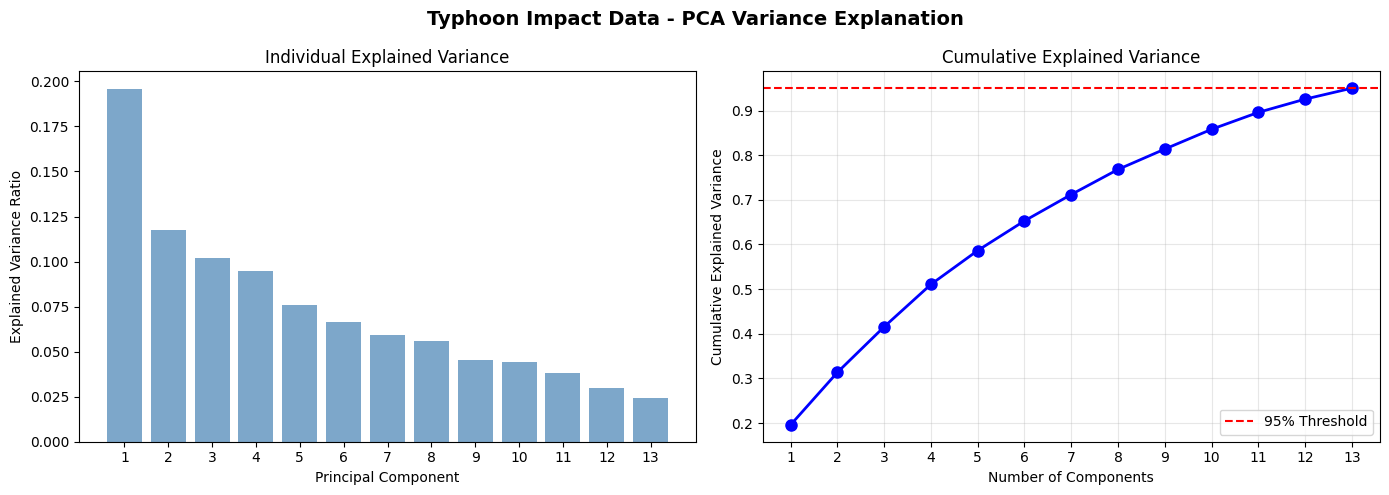

Total variance explained: 95.02%


In [17]:
# Run PCA pipeline on typhoon impact data
typhoon_pca_results = {}
numerical_features_df, categorical_features_df, numerical_column_names = prepare_pca_features(df, None)
scaled_features_array, feature_scaler_object = scale_numerical_features(numerical_features_df)
pca_transformed_array, fitted_pca_object, explained_variance_ratios = perform_pca_analysis(scaled_features_array, None, 0.95)
typhoon_pca_df = create_pca_dataframe(pca_transformed_array, fitted_pca_object.n_components_)
plot_pca_variance_explanation(fitted_pca_object, 'Typhoon Impact Data - PCA Variance Explanation')
print(f'Total variance explained: {np.sum(explained_variance_ratios)*100:.2f}%')

## 2D and 3D PCA Plots

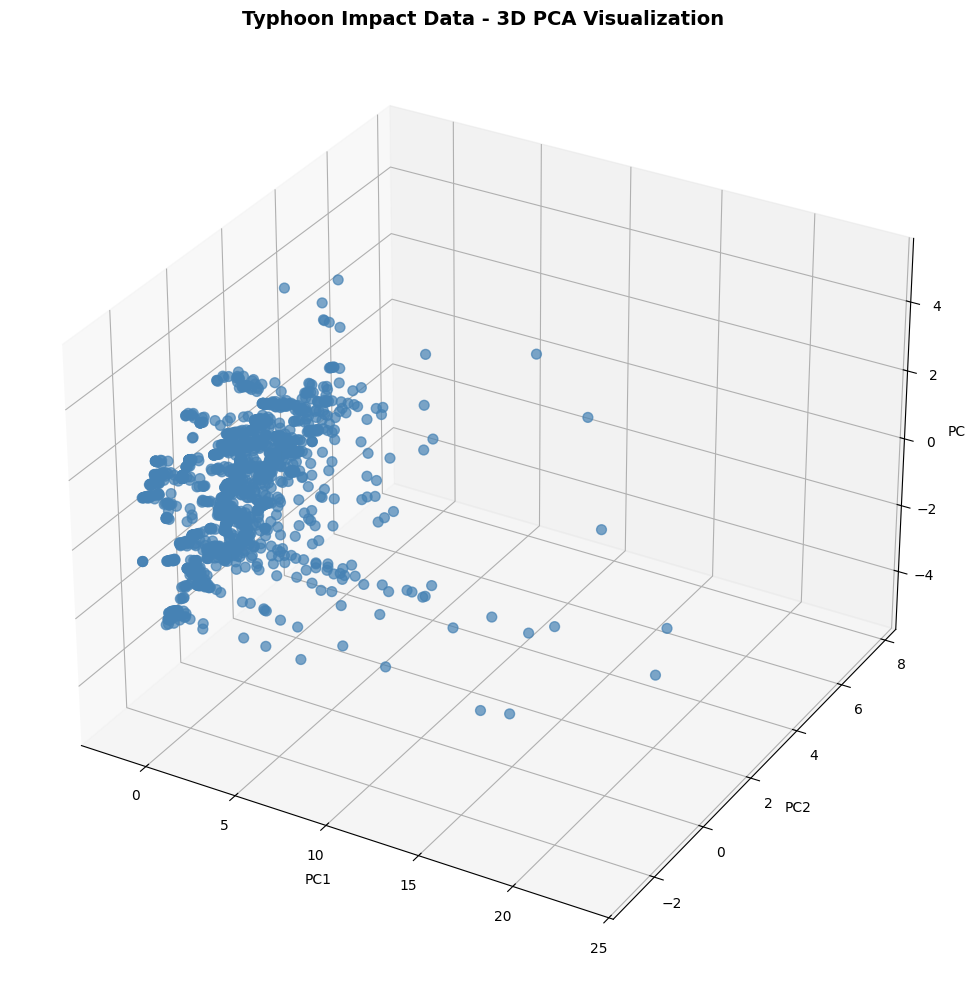

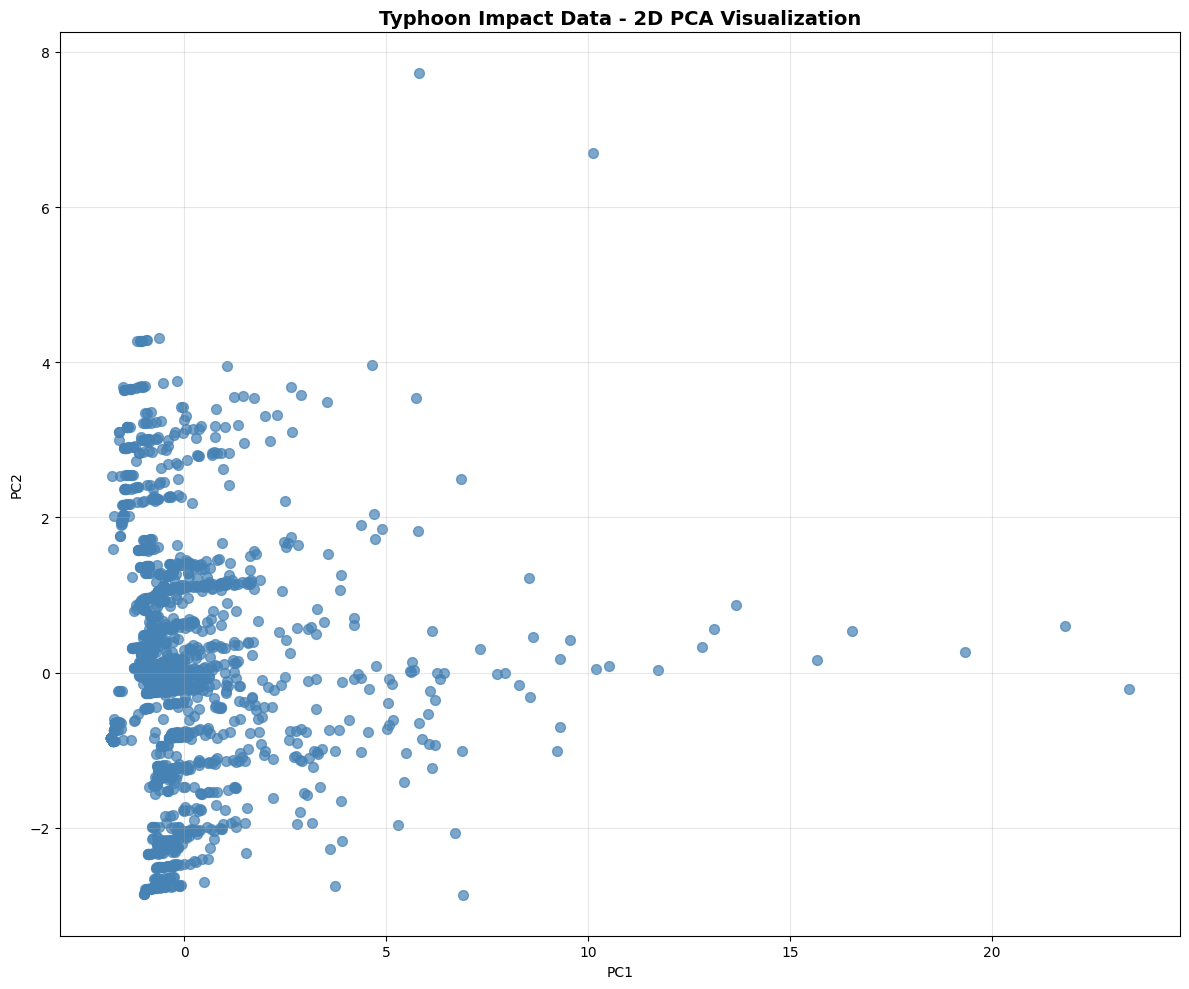

In [18]:
def plot_pca_3d(pca_dataframe: pd.DataFrame, cluster_labels: np.ndarray = None, figure_title: str = 'PCA 3D Visualization') -> None:
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    pc1_values = pca_dataframe['PC1'].values
    pc2_values = pca_dataframe['PC2'].values
    pc3_values = pca_dataframe['PC3'].values if 'PC3' in pca_dataframe.columns else np.zeros_like(pc1_values)
    if cluster_labels is not None:
        scatter_plot = ax.scatter(pc1_values, pc2_values, pc3_values, c=cluster_labels, cmap='viridis', s=50, alpha=0.7)
        fig.colorbar(scatter_plot, ax=ax, label='Cluster')
    else:
        ax.scatter(pc1_values, pc2_values, pc3_values, c='steelblue', s=50, alpha=0.7)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_zlabel('PC3')
    ax.set_title(figure_title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_pca_2d(pca_dataframe: pd.DataFrame, cluster_labels: np.ndarray = None, figure_title: str = 'PCA 2D Visualization') -> None:
    fig, ax = plt.subplots(figsize=(12, 10))
    pc1_values = pca_dataframe['PC1'].values
    pc2_values = pca_dataframe['PC2'].values
    if cluster_labels is not None:
        scatter_plot_2d = ax.scatter(pc1_values, pc2_values, c=cluster_labels, cmap='viridis', s=50, alpha=0.7)
        fig.colorbar(scatter_plot_2d, ax=ax, label='Cluster')
    else:
        ax.scatter(pc1_values, pc2_values, c='steelblue', s=50, alpha=0.7)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(figure_title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

# Preview PCA projections without clusters
plot_pca_3d(typhoon_pca_df, figure_title='Typhoon Impact Data - 3D PCA Visualization')
plot_pca_2d(typhoon_pca_df, figure_title='Typhoon Impact Data - 2D PCA Visualization')

## Standard Scaling
Scale the numerical features prior to clustering.

In [19]:
scaler = StandardScaler()
df_clean = df.copy()
df_scaled = scaler.fit_transform(df_clean)
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
display(df.head())
display(df_scaled.head())

,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_records_found,region_2,region_3,region_5,region_8
0,3608,11120,6,0,0,0,0,0,2646179.36,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
1,968,3028,5,0,0,0,0,0,494592.00,133.0,195,4,20.3,32.71,1000.5,6,1,0,0,0
2,444,1532,4,0,0,0,0,0,227328.00,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
3,575,1792,4,0,0,0,0,0,291082.96,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0
4,575,1955,6,0,0,0,0,0,296521.75,133.0,195,4,25.6,39.00,977.1,6,1,0,0,0


,families,person,brgy,dead,injured/ill,missing,totally,partially,cost,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_records_found,region_2,region_3,region_5,region_8
0,0.627959,0.432912,-0.245512,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,1.833588,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,0.309408,2.161972,-0.557406,-0.776459,-0.51649
1,-0.096344,-0.147600,-0.332928,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,0.147222,0.422971,1.093216,1.133352,-1.173803,-1.226523,0.466233,0.309408,2.161972,-0.557406,-0.776459,-0.51649
2,-0.240108,-0.254921,-0.420344,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,-0.062254,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,0.309408,2.161972,-0.557406,-0.776459,-0.51649
3,-0.204167,-0.236269,-0.420344,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,-0.012284,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,0.309408,2.161972,-0.557406,-0.776459,-0.51649
4,-0.204167,-0.224576,-0.245512,-0.04519,-0.121532,-0.050655,-0.140446,-0.198449,-0.008021,0.422971,1.093216,1.133352,-1.099347,-1.169851,-1.861117,0.309408,2.161972,-0.557406,-0.776459,-0.51649


## Optuna Optimization for Agglomerative (Complete)
Optimize hyperparameters while keeping strictly 3 clusters.

In [20]:
# Agglomerative Clustering with Optuna Optimization (strictly 3 clusters)
def optuna_agglo_complete_objective(trial, data):
    """Optuna objective for Agglomerative (complete) optimization with fixed 3 clusters."""
    n_clusters = 3  # Fixed to 3 clusters
    
    # Optimize distance threshold (set to None when using n_clusters)
    # We can still optimize the metric used for computing linkage
    metric = trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'cosine'])
    
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage='complete',
        metric=metric
    )
    labels = model.fit_predict(data)
    
    # Require at least 2 clusters
    if len(np.unique(labels)) < 2:
        return -1.0
    
    return silhouette_score(data, labels)

# Run Optuna optimization
print("Running Optuna optimization for Agglomerative Clustering (Complete Linkage, 3 clusters)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)
agglo_study = optuna.create_study(direction='maximize', study_name='agglo_complete_3clusters_optimization')
agglo_study.optimize(
    lambda t: optuna_agglo_complete_objective(t, df_scaled.values),
    n_trials=50,
    show_progress_bar=True
)

print(f"\nBest parameters found:")
print(f"  - n_clusters: 3 (fixed)")
print(f"  - metric: {agglo_study.best_params['metric']}")
print(f"  - Best Silhouette Score: {agglo_study.best_value:.4f}")

Running Optuna optimization for Agglomerative Clustering (Complete Linkage, 3 clusters)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best parameters found:
  - n_clusters: 3 (fixed)
  - metric: euclidean
  - Best Silhouette Score: 0.8312


## Train Final Agglomerative (Complete) and Evaluate

In [21]:
# Train final model with best parameters (3 clusters)
best_metric = agglo_study.best_params['metric']
agg_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='complete',
    metric=best_metric
)
cluster_labels = agg_model.fit_predict(df_scaled.values)

# Calculate metrics
silhouette = silhouette_score(df_scaled.values, cluster_labels)
calinski = calinski_harabasz_score(df_scaled.values, cluster_labels)
davies = davies_bouldin_score(df_scaled.values, cluster_labels)

print("=" * 60)
print("AGGLOMERATIVE CLUSTERING (COMPLETE LINKAGE) RESULTS")
print("=" * 60)
print(f"\nModel Parameters:")
print(f"  - n_clusters: 3")
print(f"  - linkage: complete")
print(f"  - metric: {best_metric}")
print(f"\nClustering Metrics:")
print(f"  - Silhouette Score: {silhouette:.4f}")
print(f"  - Calinski-Harabasz Index: {calinski:.4f}")
print(f"  - Davies-Bouldin Index: {davies:.4f}")
print("=" * 60)

AGGLOMERATIVE CLUSTERING (COMPLETE LINKAGE) RESULTS

Model Parameters:
  - n_clusters: 3
  - linkage: complete
  - metric: euclidean

Clustering Metrics:
  - Silhouette Score: 0.8312
  - Calinski-Harabasz Index: 89.2754
  - Davies-Bouldin Index: 0.3744


## 2D and 3D Cluster Visualization

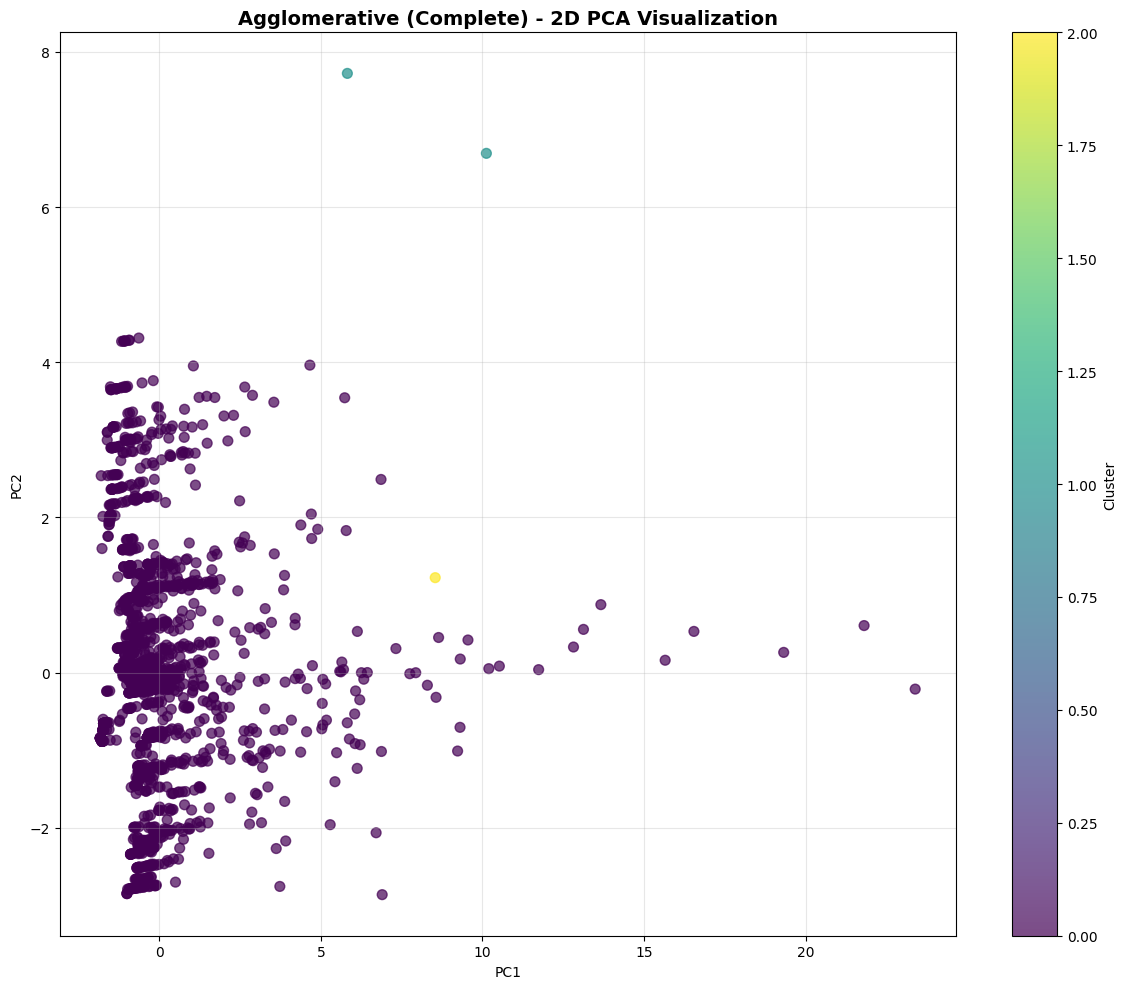

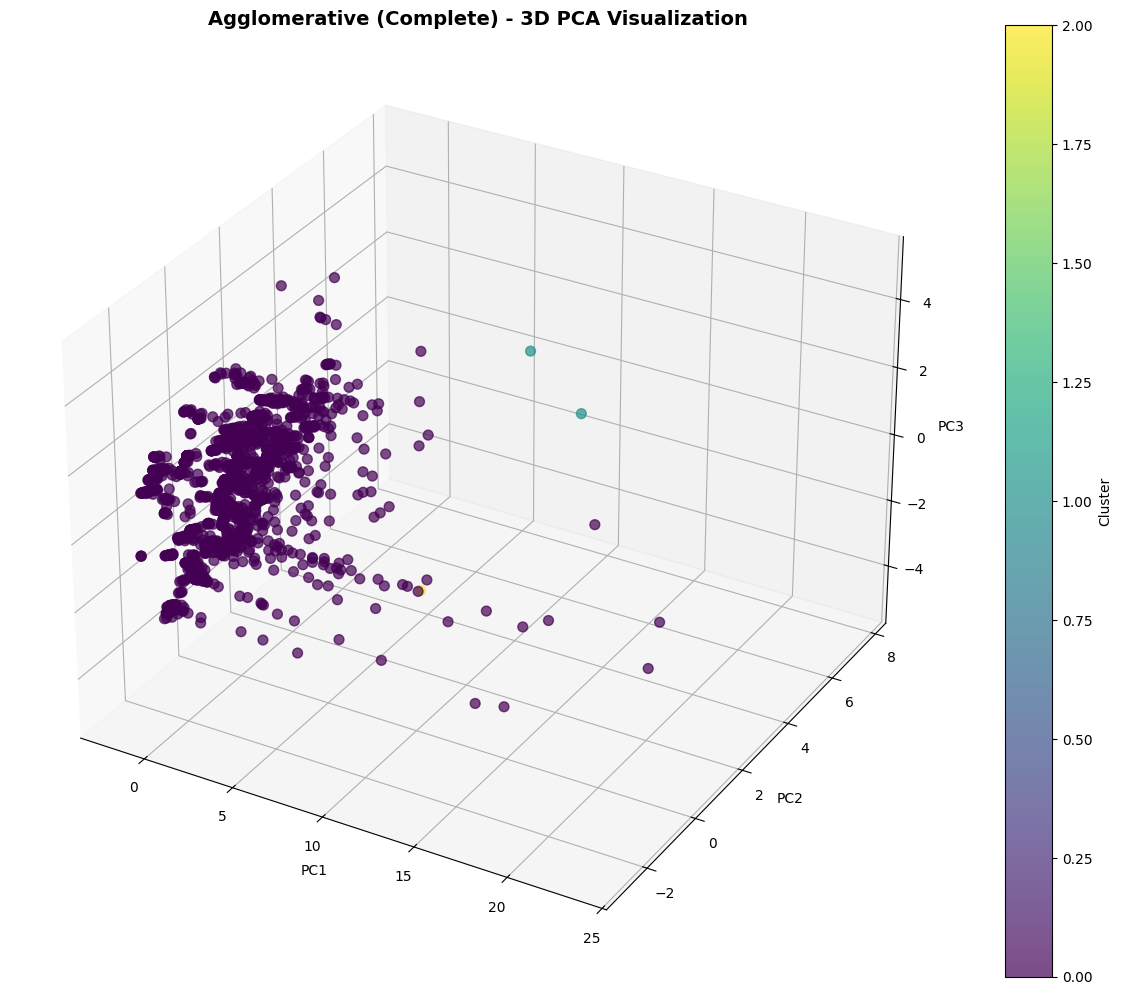

In [22]:
# Add cluster labels to PCA dataframe
typhoon_pca_df['cluster'] = cluster_labels

# 2D plot
plot_pca_2d(typhoon_pca_df, cluster_labels, figure_title='Agglomerative (Complete) - 2D PCA Visualization')
# 3D plot
plot_pca_3d(typhoon_pca_df, cluster_labels, figure_title='Agglomerative (Complete) - 3D PCA Visualization')

## Optuna Optimization for Agglomerative (Ward)
Optimize hyperparameters for Ward linkage while keeping strictly 3 clusters.
Note: Ward linkage only supports Euclidean distance.

In [23]:
# Agglomerative Clustering with Ward Linkage - Optuna Optimization (strictly 3 clusters)
def optuna_agglo_ward_objective(trial, data):
    """Optuna objective for Agglomerative (ward) optimization with fixed 3 clusters."""
    n_clusters = 3  # Fixed to 3 clusters
    
    # Ward linkage only supports Euclidean distance
    # We can optimize compute_full_tree parameter
    compute_full_tree = trial.suggest_categorical('compute_full_tree', ['auto', True, False])
    
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage='ward',
        metric='euclidean',
        compute_full_tree=compute_full_tree
    )
    labels = model.fit_predict(data)
    
    # Require at least 2 clusters
    if len(np.unique(labels)) < 2:
        return -1.0
    
    return silhouette_score(data, labels)

# Run Optuna optimization for Ward linkage
print("Running Optuna optimization for Agglomerative Clustering (Ward Linkage, 3 clusters)...")
optuna.logging.set_verbosity(optuna.logging.WARNING)
agglo_ward_study = optuna.create_study(direction='maximize', study_name='agglo_ward_3clusters_optimization')
agglo_ward_study.optimize(
    lambda t: optuna_agglo_ward_objective(t, df_scaled.values),
    n_trials=50,
    show_progress_bar=True
)

print(f"\nBest parameters found:")
print(f"  - n_clusters: 3 (fixed)")
print(f"  - linkage: ward")
print(f"  - metric: euclidean (required for Ward)")
print(f"  - compute_full_tree: {agglo_ward_study.best_params['compute_full_tree']}")
print(f"  - Best Silhouette Score: {agglo_ward_study.best_value:.4f}")

Running Optuna optimization for Agglomerative Clustering (Ward Linkage, 3 clusters)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best parameters found:
  - n_clusters: 3 (fixed)
  - linkage: ward
  - metric: euclidean (required for Ward)
  - compute_full_tree: False
  - Best Silhouette Score: 0.1340


## Train Final Agglomerative (Ward) and Evaluate

In [24]:
# Train final Ward model with best parameters (3 clusters)
best_compute_full_tree = agglo_ward_study.best_params['compute_full_tree']
agg_ward_model = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward',
    metric='euclidean',
    compute_full_tree=best_compute_full_tree
)
ward_cluster_labels = agg_ward_model.fit_predict(df_scaled.values)

# Calculate metrics
ward_silhouette = silhouette_score(df_scaled.values, ward_cluster_labels)
ward_calinski = calinski_harabasz_score(df_scaled.values, ward_cluster_labels)
ward_davies = davies_bouldin_score(df_scaled.values, ward_cluster_labels)

print("=" * 60)
print("AGGLOMERATIVE CLUSTERING (WARD LINKAGE) RESULTS")
print("=" * 60)
print(f"\nModel Parameters:")
print(f"  - n_clusters: 3")
print(f"  - linkage: ward")
print(f"  - metric: euclidean")
print(f"  - compute_full_tree: {best_compute_full_tree}")
print(f"\nClustering Metrics:")
print(f"  - Silhouette Score: {ward_silhouette:.4f}")
print(f"  - Calinski-Harabasz Index: {ward_calinski:.4f}")
print(f"  - Davies-Bouldin Index: {ward_davies:.4f}")
print("=" * 60)

AGGLOMERATIVE CLUSTERING (WARD LINKAGE) RESULTS

Model Parameters:
  - n_clusters: 3
  - linkage: ward
  - metric: euclidean
  - compute_full_tree: False

Clustering Metrics:
  - Silhouette Score: 0.1340
  - Calinski-Harabasz Index: 193.6152
  - Davies-Bouldin Index: 2.2735


## 2D and 3D Cluster Visualization (Ward Linkage)

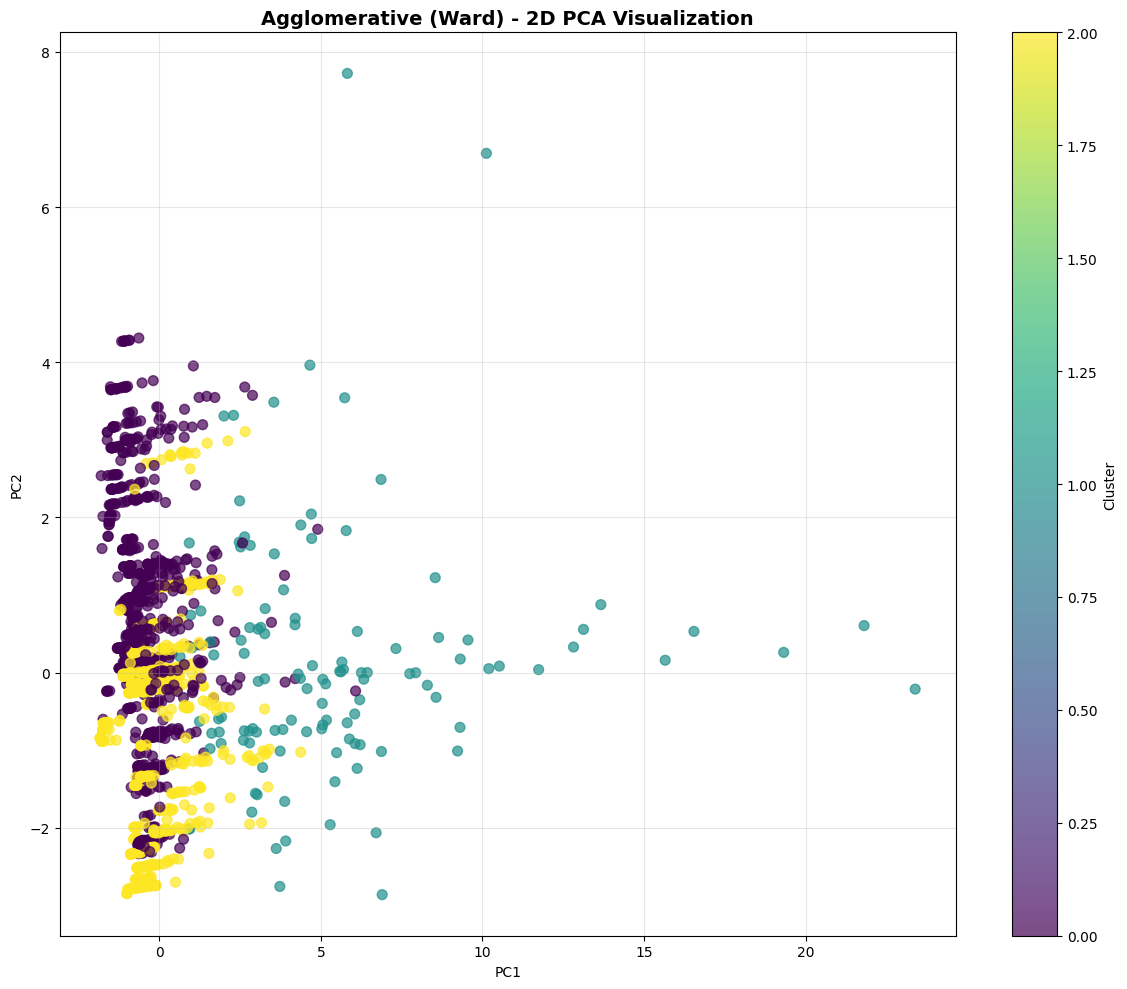

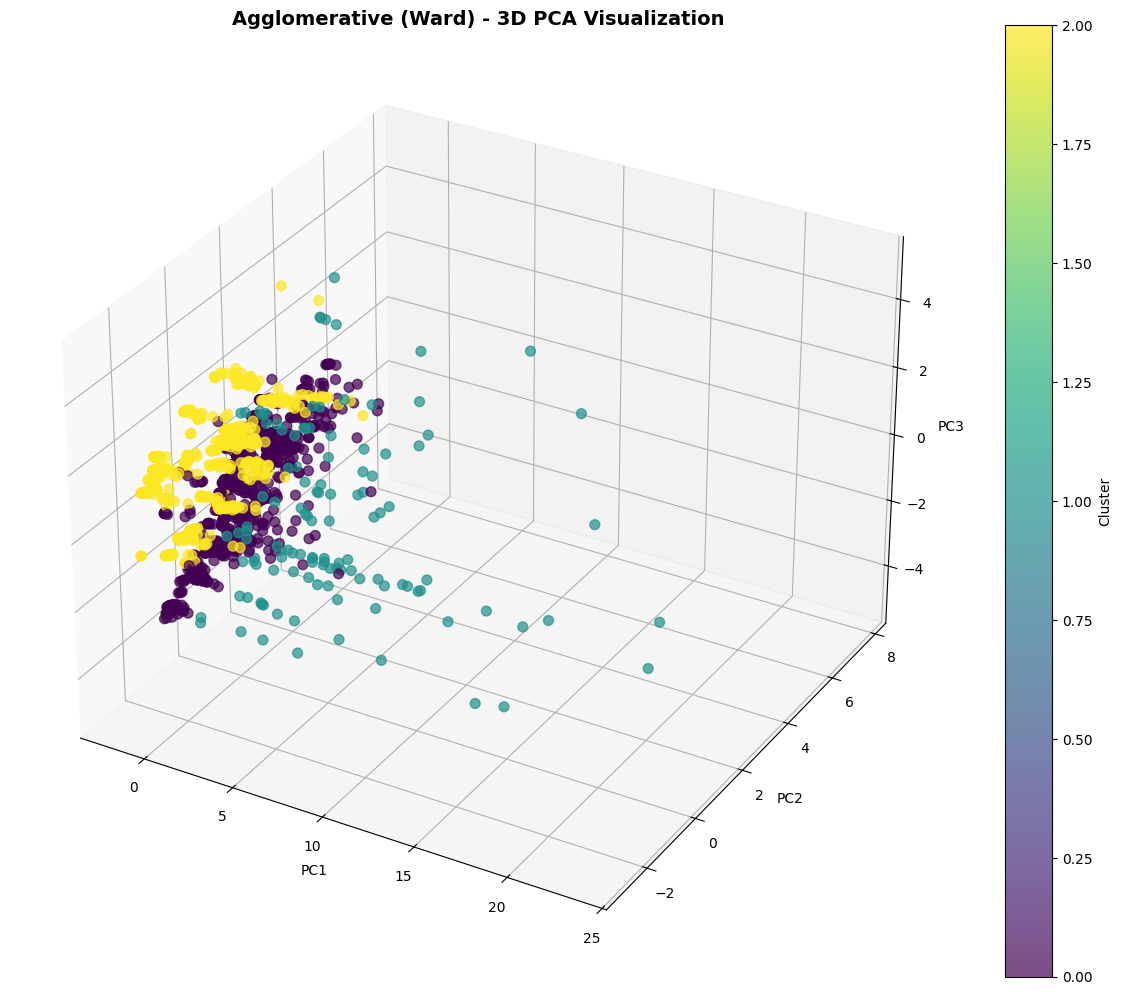

In [25]:
# Add Ward cluster labels to PCA dataframe
typhoon_pca_df['ward_cluster'] = ward_cluster_labels

# 2D plot for Ward
plot_pca_2d(typhoon_pca_df, ward_cluster_labels, figure_title='Agglomerative (Ward) - 2D PCA Visualization')
# 3D plot for Ward
plot_pca_3d(typhoon_pca_df, ward_cluster_labels, figure_title='Agglomerative (Ward) - 3D PCA Visualization')

## Comparison: Complete vs Ward Linkage

In [26]:
# Create comparison table
comparison_data = {
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Index', 'Davies-Bouldin Index'],
    'Complete Linkage': [silhouette, calinski, davies],
    'Ward Linkage': [ward_silhouette, ward_calinski, ward_davies]
}
comparison_df = pd.DataFrame(comparison_data)

print("=" * 70)
print("COMPARISON: COMPLETE LINKAGE vs WARD LINKAGE")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

# Determine better model based on Silhouette Score
if silhouette > ward_silhouette:
    print("\n>> Complete Linkage has better Silhouette Score")
else:
    print("\n>> Ward Linkage has better Silhouette Score")

# Note: Higher Silhouette and Calinski-Harabasz are better, Lower Davies-Bouldin is better

COMPARISON: COMPLETE LINKAGE vs WARD LINKAGE
                 Metric  Complete Linkage  Ward Linkage
       Silhouette Score          0.831209      0.134018
Calinski-Harabasz Index         89.275402    193.615233
   Davies-Bouldin Index          0.374363      2.273457

>> Complete Linkage has better Silhouette Score
